In [1]:
import pandas as pd

df = pd.read_csv("../data/raw_metadata.csv")
print(df.head())
print("Dataset shape:", df.shape)

      video_id                                              title  \
0  KGVpKPNUdzA  Khabib vs Lex: Training with Khabib | FULL EXC...   
1  YFjfBk8HI5o  OpenClaw: The Viral AI Agent that Broke the In...   
2  EV7WhVT270Q  State of AI in 2026: LLMs, Coding, Scaling Law...   
3  Z-FRe5AKmCU  Paul Rosolie: Uncontacted Tribes in the Amazon...   
4  14OPT6CcsH4  Infinity, Paradoxes, Gödel Incompleteness &amp...   

  published_date  
0     2026-02-25  
1     2026-02-12  
2     2026-01-31  
3     2026-01-13  
4     2025-12-31  
Dataset shape: (225, 3)


In [2]:
print("Columns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nTotal rows:", len(df))
required_cols = ["video_id", "title", "published_date"]
for col in required_cols:
    print(f"{col} exists:", col in df.columns)

Columns: ['video_id', 'title', 'published_date']

Data types:
video_id          object
title             object
published_date    object
dtype: object

Total rows: 225
video_id exists: True
title exists: True
published_date exists: True


In [3]:
duplicate_ids = df["video_id"].duplicated().sum()
print("Duplicate video_id count:", duplicate_ids)
duplicate_titles = df["title"].duplicated().sum()
print("Duplicate title count:", duplicate_titles)
df = df.drop_duplicates(subset="video_id")
print("New dataset shape after removing duplicates:", df.shape)

Duplicate video_id count: 0
Duplicate title count: 0
New dataset shape after removing duplicates: (225, 3)


In [4]:
print("Null values:\n")
print(df.isnull().sum())

Null values:

video_id          0
title             0
published_date    0
dtype: int64


In [5]:
df["published_date"] = pd.to_datetime(df["published_date"])
df["year"] = df["published_date"].dt.year
df["month"] = df["published_date"].dt.month
df.head()

,video_id,title,published_date,year,month
0,KGVpKPNUdzA,Khabib vs Lex: Training with Khabib | FULL EXC...,2026-02-25,2026,2
1,YFjfBk8HI5o,OpenClaw: The Viral AI Agent that Broke the In...,2026-02-12,2026,2
2,EV7WhVT270Q,"State of AI in 2026: LLMs, Coding, Scaling Law...",2026-01-31,2026,1
3,Z-FRe5AKmCU,Paul Rosolie: Uncontacted Tribes in the Amazon...,2026-01-13,2026,1
4,14OPT6CcsH4,"Infinity, Paradoxes, Gödel Incompleteness &amp...",2025-12-31,2025,12


year
2019    25
2020    30
2021    45
2022    40
2023    28
2024    28
2025    25
2026     4
Name: count, dtype: int64


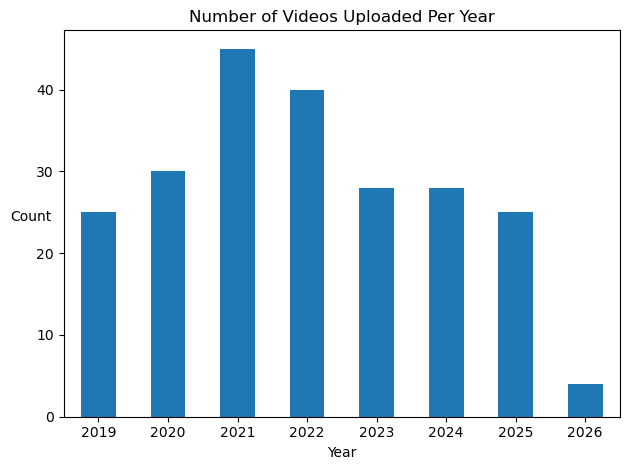

month
1     15
2     16
3     14
4     16
5     19
6     18
7     24
8     23
9     18
10    12
11    31
12    19
Name: count, dtype: int64


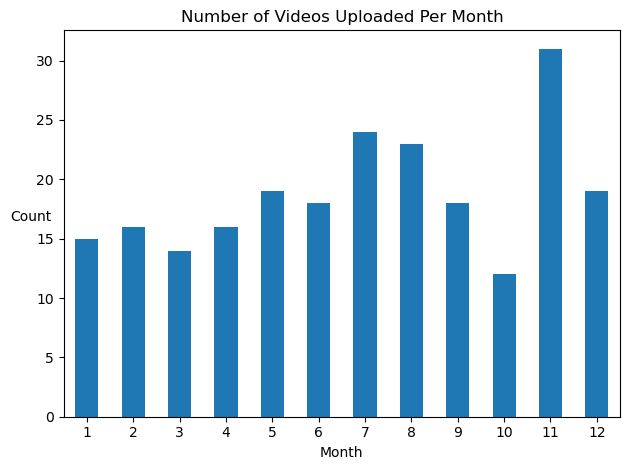

In [13]:
import matplotlib.pyplot as plt

videos_per_year = df["year"].value_counts().sort_index()
print(videos_per_year)

plt.figure()
videos_per_year.plot(kind="bar")
plt.title("Number of Videos Uploaded Per Year")
plt.xlabel("Year")
plt.ylabel("Count", rotation=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

videos_per_month = df["month"].value_counts().sort_index()
print(videos_per_month)

plt.figure()
videos_per_month.plot(kind="bar")
plt.title("Number of Videos Uploaded Per Month")
plt.xlabel("Month")
plt.ylabel("Count", rotation=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Shortest title length: 20
Longest title length: 107
Average title length: 82.27111111111111


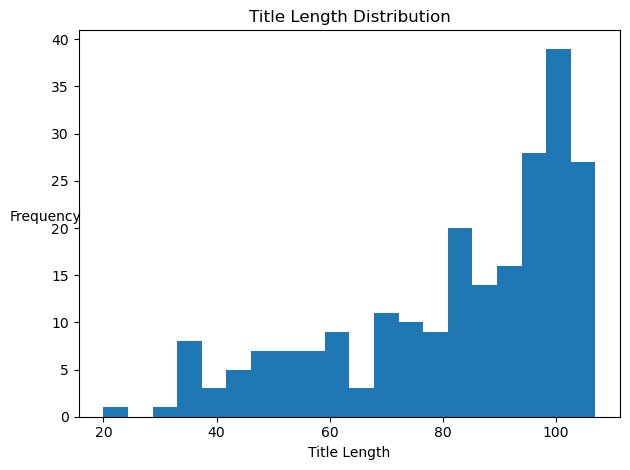

In [7]:
df["title_length"] = df["title"].apply(len)

print("Shortest title length:", df["title_length"].min())
print("Longest title length:", df["title_length"].max())
print("Average title length:", df["title_length"].mean())

plt.figure()
plt.hist(df["title_length"], bins=20)
plt.title("Title Length Distribution")
plt.xlabel("Title Length")
plt.ylabel("Frequency", rotation=0)
plt.tight_layout()
plt.show()

In [8]:
print("Total unique videos:", df["video_id"].nunique())

print("\nDate range:")
print("Start:", df["published_date"].min())
print("End:", df["published_date"].max())

Total unique videos: 225

Date range:
Start: 2019-11-02 00:00:00
End: 2026-02-25 00:00:00


In [9]:
df["title"] = (
    df["title"]
    .str.strip()
    .str.replace("\n", " ", regex=False)
    .str.replace("  ", " ", regex=False)
)
df.head()

,video_id,title,published_date,year,month,title_length
0,KGVpKPNUdzA,Khabib vs Lex: Training with Khabib | FULL EXC...,2026-02-25,2026,2,60
1,YFjfBk8HI5o,OpenClaw: The Viral AI Agent that Broke the In...,2026-02-12,2026,2,99
2,EV7WhVT270Q,"State of AI in 2026: LLMs, Coding, Scaling Law...",2026-01-31,2026,1,100
3,Z-FRe5AKmCU,Paul Rosolie: Uncontacted Tribes in the Amazon...,2026-01-13,2026,1,80
4,14OPT6CcsH4,"Infinity, Paradoxes, Gödel Incompleteness &amp...",2025-12-31,2025,12,102


In [10]:
df.to_csv("../data/cleaned_metadata.csv", index=False)
print("Cleaned dataset saved as cleaned_metadata.csv")

Cleaned dataset saved as cleaned_metadata.csv
